In [1]:
print("Everything is ok!!!")

Everything is ok!!!


##### Step 1: Create tools that the agent can use

In [2]:
# Import tools: ArxivQueryRun, WikipediaQueryRun from Langchain_community.tools
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun

# Import wrapper to use these tools with LLM
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

from langchain_tavily import TavilySearch

##### Step 2: Creating Environment Variables for APIs

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
#os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
#os.environ["LANGCHAIN_TRACING_V2"] = "true"
#os.environ["LANGCHAIN_PROJECT"] = "Re-Act_Agent"

In [4]:
api_wrapper_arxiv = ArxivAPIWrapper()

arxiv = ArxivQueryRun(api_wrapper = api_wrapper_arxiv)

api_wrapper_wikipedia = WikipediaAPIWrapper()

wikipedia = WikipediaQueryRun(api_wrapper = api_wrapper_wikipedia)

tavily_tool = TavilySearch()

In [5]:
arxiv.run("ReAct: Synergizing Reasoning and Acting in Language Models")

'Published: 2023-03-10\nTitle: ReAct: Synergizing Reasoning and Acting in Language Models\nAuthors: Shunyu Yao, Jeffrey Zhao, Dian Yu, Nan Du, Izhak Shafran, Karthik Narasimhan, Yuan Cao\nSummary: While large language models (LLMs) have demonstrated impressive capabilities across tasks in language understanding and interactive decision making, their abilities for reasoning (e.g. chain-of-thought prompting) and acting (e.g. action plan generation) have primarily been studied as separate topics. In this paper, we explore the use of LLMs to generate both reasoning traces and task-specific actions in an interleaved manner, allowing for greater synergy between the two: reasoning traces help the model induce, track, and update action plans as well as handle exceptions, while actions allow it to interface with external sources, such as knowledge bases or environments, to gather additional information. We apply our approach, named ReAct, to a diverse set of language and decision making tasks a

In [7]:
wikipedia.run("What is ReAct: Synergizing Reasoning and Acting in Language Models?")

'Page: AI agent\nSummary: In the context of generative artificial intelligence, AI agents (also referred to as compound AI systems or agentic AI) are a class of intelligent agents distinguished by their ability to operate autonomously in complex environments. Agentic AI tools prioritize decision-making over content creation and do not require continuous oversight.\n\n'

In [9]:
tavily_tool.invoke("Provide me the today's 19th April 2026 IPL News.")

{'query': "Provide me the today's 19th April 2026 IPL News.",
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://timesofindia.indiatimes.com/sports/cricket/ipl',
   'title': 'Indian Premier League (IPL) 2026 - The Times of India',
   'content': 'Apr 15 2026. Royal Challengers Bengaluru beat Lucknow Super Giants by 5 wickets. PBKS. Apr 19 2026. Match Centre. RR. Apr 22 2026. Match Centre. KKR. Apr 26',
   'score': 0.7975099,
   'raw_content': None},
  {'url': 'https://www.crictracker.com/t20/ipl-indian-premier-league/',
   'title': 'IPL 2026 Live Score | IPL News Today, Predictions, Updates & Scores',
   'content': "Calender 19 Apr 2026 Clock 2 Min. Blessing Muzarabani. Blessing Muzarabani's agent hits back at PSL's two-year ban. Calender 19 Apr 2026 Clock",
   'score': 0.75290436,
   'raw_content': None},
  {'url': 'https://www.cricbuzz.com/cricket-series/9241/indian-premier-league-2026/news',
   'title': 'IPL | Indian Premier League 2026 News |

In [10]:
# Custom functions for Re-Act Agent
from langchain.tools import tool

@tool
def multiply(a:int, b:int) -> int:

    """ Multiplies two numbers.

    Args:
        a (int): First number
        b (int): Second number

    Returns:
        int: Product of the two numbers
    """
    return a * b
@tool
def divide(a:int, b:int) -> int:

    """ Divides two numbers.

    Args:
        a (int): First number
        b (int): Second number

    Returns:
        int: Sum of the two numbers
    """
    return a / b    
@tool
def subtract(a:int, b:int) -> int:

    """ Subtracts two numbers.

    Args:
        a (int): First number
        b (int): Second number

    Returns:
        int: Difference of the two numbers
    """
    return a - b

d:\GENAIBatch\langchain_new\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
subtract.invoke({"a": 10, "b": 5})

5

In [12]:
tools = [arxiv, wikipedia, tavily_tool, multiply, divide, subtract]

os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "Re-Act_Agent"

##### Step 2: Load LLM

In [13]:
# Initialize my llm model 

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model = "gpt-4o")

##### Step 3: Combined LLM with Tools

In [14]:
# Bind will tools means now the llm will have the knowledge that i has the access to these tools 
llm_with_tools = llm.bind_tools(tools)

In [15]:
llm_with_tools

RunnableBinding(bound=ChatOpenAI(profile={'name': 'GPT-4o', 'release_date': '2024-05-13', 'last_updated': '2024-08-06', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000020CAA1D2F90>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000020CAA1D3A10>, root_client=<openai.OpenAI object at 0x0000020CAA1D0440>, root_async_client=<openai.AsyncOpenAI object at 0x0000020CAA1D3770>, model_name='gpt-4o', model_kwargs={}, openai_ap

In [16]:
from langchain_core.messages import HumanMessage, AIMessage
from pprint import pprint

llm_with_tools.invoke([HumanMessage(content="What is the recent AI news?")])

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 1477, 'total_tokens': 1499, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_071222c984', 'id': 'chatcmpl-DWMnBBYlFZhv9RA5dCELsOJaRRRxQ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019da5ff-7fb5-7b42-b9da-ac20b44a191e-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'topic': 'news'}, 'id': 'call_MIrzZKL7fxD5pBCE09BCkKmE', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1477, 'output_tokens': 22, 'total_tokens': 1499, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, '

In [17]:
llm_with_tools.invoke([HumanMessage(content="What is the recent AI news?")]).tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'recent AI news', 'topic': 'news'},
  'id': 'call_B3O8mlwHflv4vLwSuaAcP0vV',
  'type': 'tool_call'}]

In [18]:
llm_with_tools.invoke([HumanMessage(content="What is 45 divided by 5?")])

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 1479, 'total_tokens': 1496, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1408}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_071222c984', 'id': 'chatcmpl-DWMoiuAeUKe1a8W4t9mA3TM0TJYJp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019da600-f77c-7883-908b-d75446a1511f-0', tool_calls=[{'name': 'divide', 'args': {'a': 45, 'b': 5}, 'id': 'call_PjyD8zZGfbWy9SKyEXAwXTPv', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1479, 'output_tokens': 17, 'total_tokens': 1496, 'input_token_details': {'audio': 0, 'cache_read': 1408}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [19]:
llm_with_tools.invoke([HumanMessage(content="What is 45 divided by 5?")]).tool_calls

[{'name': 'divide',
  'args': {'a': 45, 'b': 5},
  'id': 'call_aL238GTk96vYD4bbV8OR01yk',
  'type': 'tool_call'}]

##### Step 4: Create ReAct Workflow

In [20]:
# State Schema

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
# AnyMessage is a type alias that unifies all possible message types in LangChain. It simplifies handling sequences of mixed messages (human, AI, system, tool, etc.) without needing to specify each type individually.
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [21]:
# Define the llm node

def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

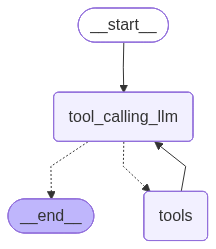

In [23]:
# Building a ReAct Agent chatbot with LangGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition 
# ToolNode - A node for executing tools in LangGraph workflows. It takes a list of tools and executes any that are called by the LLM, returning their outputs back into the workflow state.
from IPython.display import display, Image

# Define the state graph
builder = StateGraph(State)

# Add the node
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add the edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

# Compile the graph
graph = builder.compile(name = "react_agent")

# Display the graph
Image(graph.get_graph().draw_mermaid_png())


#### Step 5: Invocation

In [24]:
# Invocation

messages = graph.invoke(
    {"messages": [HumanMessage(content="Provide me 10 recent AI news for March 2026, add 5 plus 5 and then multiply by 10.")]})

for msg in messages['messages']:
    msg.pretty_print()

================================ Human Message =================================

Provide me 10 recent AI news for March 2026, add 5 plus 5 and then multiply by 10.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_08NPgV1tjZbgS0KYowPvvU42)
 Call ID: call_08NPgV1tjZbgS0KYowPvvU42
  Args:
    query: AI news
    time_range: month
    topic: news
  multiply (call_rgCzduUYZ2dYziWgTwd0vo99)
 Call ID: call_rgCzduUYZ2dYziWgTwd0vo99
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.adweek.com/media/quicken-is-producing-100-pieces-of-content-every-few-weeks-using-ai/", "title": "Quicken Is Producing 100 Pieces of Content Every Few Weeks Using AI - ADWEEK", "score": 0.7283819, "published_date": "Fri, 20 Mar 2026 10:00:00 GMT", "content": "###

In [25]:
# Invocation

messages = graph.invoke(
    {"messages": [HumanMessage(content="Add 50 to the result.")]})

for msg in messages['messages']:
    msg.pretty_print()

================================ Human Message =================================

Add 50 to the result.
================================== Ai Message ==================================

It seems like you're looking to add 50 to the result of a previous mathematical operation, but I need more context or a specific initial result to add 50 to. Could you please provide the initial result or clarify the operation you would like to perform?


#### Step 6: Let's introduces the Agent's Memory

In [26]:
messages = graph.invoke(
    {"messages": [HumanMessage(content="What is 15 divide 5?")]})

for msg in messages['messages']:
    msg.pretty_print()

================================ Human Message =================================

What is 15 divide 5?
================================== Ai Message ==================================
Tool Calls:
  divide (call_msB1ZKLLuS3KBrNjCkAJUQy3)
 Call ID: call_msB1ZKLLuS3KBrNjCkAJUQy3
  Args:
    a: 15
    b: 5
================================= Tool Message =================================
Name: divide

3.0
================================== Ai Message ==================================

15 divided by 5 is 3.0.


In [27]:
message = HumanMessage(content="add that to 45.")
messages = graph.invoke(
    {"messages": [message]})

for msg in messages['messages']:
    msg.pretty_print()

================================ Human Message =================================

add that to 45.
================================== Ai Message ==================================

It seems like you're asking to add a number to 45, but you haven't provided the second number. Could you please specify what you'd like to add to 45?


### Persistence

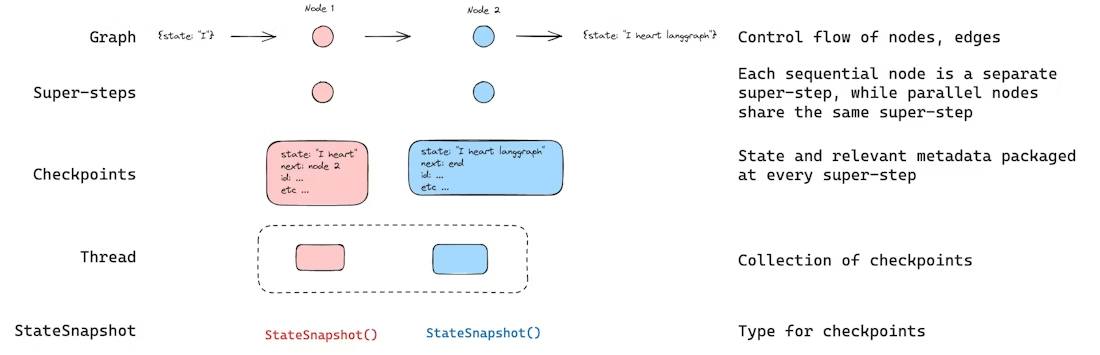

In [26]:
# Building a ReAct Agent chatbot with LangGraph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import display, Image

# Define the llm node

def tool_calling_llm(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


# Define the state graph
builder = StateGraph(State)

# Add the node
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Add the edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

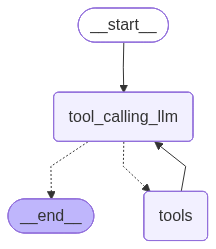

In [28]:
# Define LangGraph Memory
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
graph_memory = builder.compile(checkpointer=memory, name="react_agent_with_memory")

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [29]:
# specify the thread
# Threads are like separate “conversations” or runs of your graph. Each thread has a unique thread_id and keeps its own set of checkpoints, so its execution history stays separate and independent from other threads. This allows you to run multiple instances of the same graph in parallel without them interfering with each other’s state or checkpoints.

config = {"configurable":{"thread_id":"1"}}

message = [HumanMessage(content="Add 5 plus 15")]

messages = graph_memory.invoke({"messages":message}, config=config)

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Add 5 plus 15
================================== Ai Message ==================================

The sum of 5 plus 15 is 20.


In [30]:
message = [HumanMessage(content="multiply 5 to the previous result.")]

messages = graph_memory.invoke({"messages":message}, config=config)

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Add 5 plus 15
================================== Ai Message ==================================

The sum of 5 plus 15 is 20.
================================ Human Message =================================

multiply 5 to the previous result.
================================== Ai Message ==================================
Tool Calls:
  multiply (call_D5QU8NF9Z5BolTCSHY256QoK)
 Call ID: call_D5QU8NF9Z5BolTCSHY256QoK
  Args:
    a: 5
    b: 20
================================= Tool Message =================================
Name: multiply

100
================================== Ai Message ==================================

Multiplying 5 by 20 gives you 100.


In [41]:
# Get the current state of the graph for the specified thread
graph_memory.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='Add 5 plus 15', additional_kwargs={}, response_metadata={}, id='907a04aa-3f38-4940-af10-a7985b524534'), AIMessage(content='The sum of 5 plus 15 is 20.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 1476, 'total_tokens': 1489, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1408}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_49d177369b', 'id': 'chatcmpl-DWNIkpz1NMBroE9DqjLRKZLMViAmr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019da61d-6015-71d1-a94e-084226863ba3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1476, 'output_tokens': 13, 'total_tokens': 1489, 'input_token_details': {'audio': 0, 'cache_rea

In [42]:
# get the history of the graph for the specified thread
list(graph_memory.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='Add 5 plus 15', additional_kwargs={}, response_metadata={}, id='907a04aa-3f38-4940-af10-a7985b524534'), AIMessage(content='The sum of 5 plus 15 is 20.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 1476, 'total_tokens': 1489, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1408}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_49d177369b', 'id': 'chatcmpl-DWNIkpz1NMBroE9DqjLRKZLMViAmr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019da61d-6015-71d1-a94e-084226863ba3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1476, 'output_tokens': 13, 'total_tokens': 1489, 'input_token_details': {'audio': 0, 'cache_re

In [33]:
len(list(graph_memory.get_state_history(config)))

8

In [38]:
# Get the current state of the graph for the specified thread
graph_memory.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='Add 5 plus 15', additional_kwargs={}, response_metadata={}, id='907a04aa-3f38-4940-af10-a7985b524534'), AIMessage(content='The sum of 5 plus 15 is 20.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 1476, 'total_tokens': 1489, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1408}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_49d177369b', 'id': 'chatcmpl-DWNIkpz1NMBroE9DqjLRKZLMViAmr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019da61d-6015-71d1-a94e-084226863ba3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1476, 'output_tokens': 13, 'total_tokens': 1489, 'input_token_details': {'audio': 0, 'cache_rea

In [43]:
# Revert the graph to a previous checkpoint for the specified thread
graph_memory.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f13bfae-efa6-6322-8000-36db95000c13"}})

StateSnapshot(values={'messages': [HumanMessage(content='Add 5 plus 15', additional_kwargs={}, response_metadata={}, id='907a04aa-3f38-4940-af10-a7985b524534')]}, next=('tool_calling_llm',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f13bfae-efa6-6322-8000-36db95000c13'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-19T14:20:36.244547+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13bfae-ef99-621b-bfff-0694af8f6af7'}}, tasks=(PregelTask(id='cf67ed58-03d8-89c4-2e97-9be10716147d', name='tool_calling_llm', path=('__pregel_pull', 'tool_calling_llm'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='The sum of 5 plus 15 is 20.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 1476, 'total_tokens': 1489, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_t

In [44]:
# Revert the graph to a previous checkpoint for the specified thread
# This we use it to resume a conversation from a specific point in the past, allowing us to undo any actions or decisions made after that checkpoint and continue the conversation as if we were at that point in time.
graph_memory.invoke(None, config={"configurable": {"thread_id": "1", "checkpoint_id": "1f13bfae-efa6-6322-8000-36db95000c13"}})

{'messages': [HumanMessage(content='Add 5 plus 15', additional_kwargs={}, response_metadata={}, id='907a04aa-3f38-4940-af10-a7985b524534'),
  AIMessage(content='The sum of 5 plus 15 is 20.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 1476, 'total_tokens': 1489, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1408}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_071222c984', 'id': 'chatcmpl-DWNVCcJCw7nV8SD9B9uXyXkywZtaw', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019da629-254e-7201-b28e-b49cc23d9a87-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1476, 'output_tokens': 13, 'total_tokens': 1489, 'input_token_details': {'audio': 0, 'cache_read': 1408}, 'output_

In [45]:
graph_memory.update_state(
    {"configurable": 
        {"thread_id": "1", 
         "checkpoint_id": "1f13bfae-efa6-6322-8000-36db95000c13'", "checkpoint_ns":""}
        },
    {"messages":[HumanMessage(content="What is LangGraph?")]})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f13bfce-481d-65a8-8000-57a7709efa79'}}

In [46]:
list(graph_memory.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='What is LangGraph?', additional_kwargs={}, response_metadata={}, id='3a5ea047-9162-4779-92c3-60a975c53893')]}, next=('tool_calling_llm',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13bfce-481d-65a8-8000-57a7709efa79'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-04-19T14:34:37.670742+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': "1f13bfae-efa6-6322-8000-36db95000c13'"}}, tasks=(PregelTask(id='3c6b4fe0-14bc-a942-e963-ded82a1fc76e', name='tool_calling_llm', path=('__pregel_pull', 'tool_calling_llm'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'messages': [HumanMessage(content='Add 5 plus 15', additional_kwargs={}, response_metadata={}, id='907a04aa-3f38-4940-af10-a7985b524534'), AIMessage(content='The sum of 5 plus 15 is 20.', additional_kwargs={'refusal': Non

In [48]:
graph_memory.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f13bfce-481d-65a8-8000-57a7709efa79"}})

{'messages': [HumanMessage(content='What is LangGraph?', additional_kwargs={}, response_metadata={}, id='3a5ea047-9162-4779-92c3-60a975c53893'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 1475, 'total_tokens': 1489, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_49d177369b', 'id': 'chatcmpl-DWNWzwbgx3yBa5yEbIpK4P2wfFXzo', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019da62a-d838-72a3-add8-0e2bf7b185e9-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'LangGraph'}, 'id': 'call_tzq530ChMSfDJfa5LaQ8TN8l', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1475, 'output_tokens

In [41]:
list(graph_memory.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='What is LangGraph?', additional_kwargs={}, response_metadata={}, id='7a6d45d6-7165-4458-bd25-9d066dbdc894'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 1475, 'total_tokens': 1489, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1408}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_071222c984', 'id': 'chatcmpl-DWItUZk0Y0PTUMVdDOdMFQsEPcNSJ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019da51a-e03d-71c2-8431-1491cd44220c-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'LangGraph'}, 'id': 'call_r0VXZ0DXdlHRHKtL1eE606xR', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens